In [1]:
from google.colab import files

# Upload the dataset
uploaded = files.upload()
import pandas as pd

df = pd.read_csv('flood.csv')

Saving flood.csv to flood.csv


In [22]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import psutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

In [2]:
# Display the first few rows
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

In [4]:
df.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


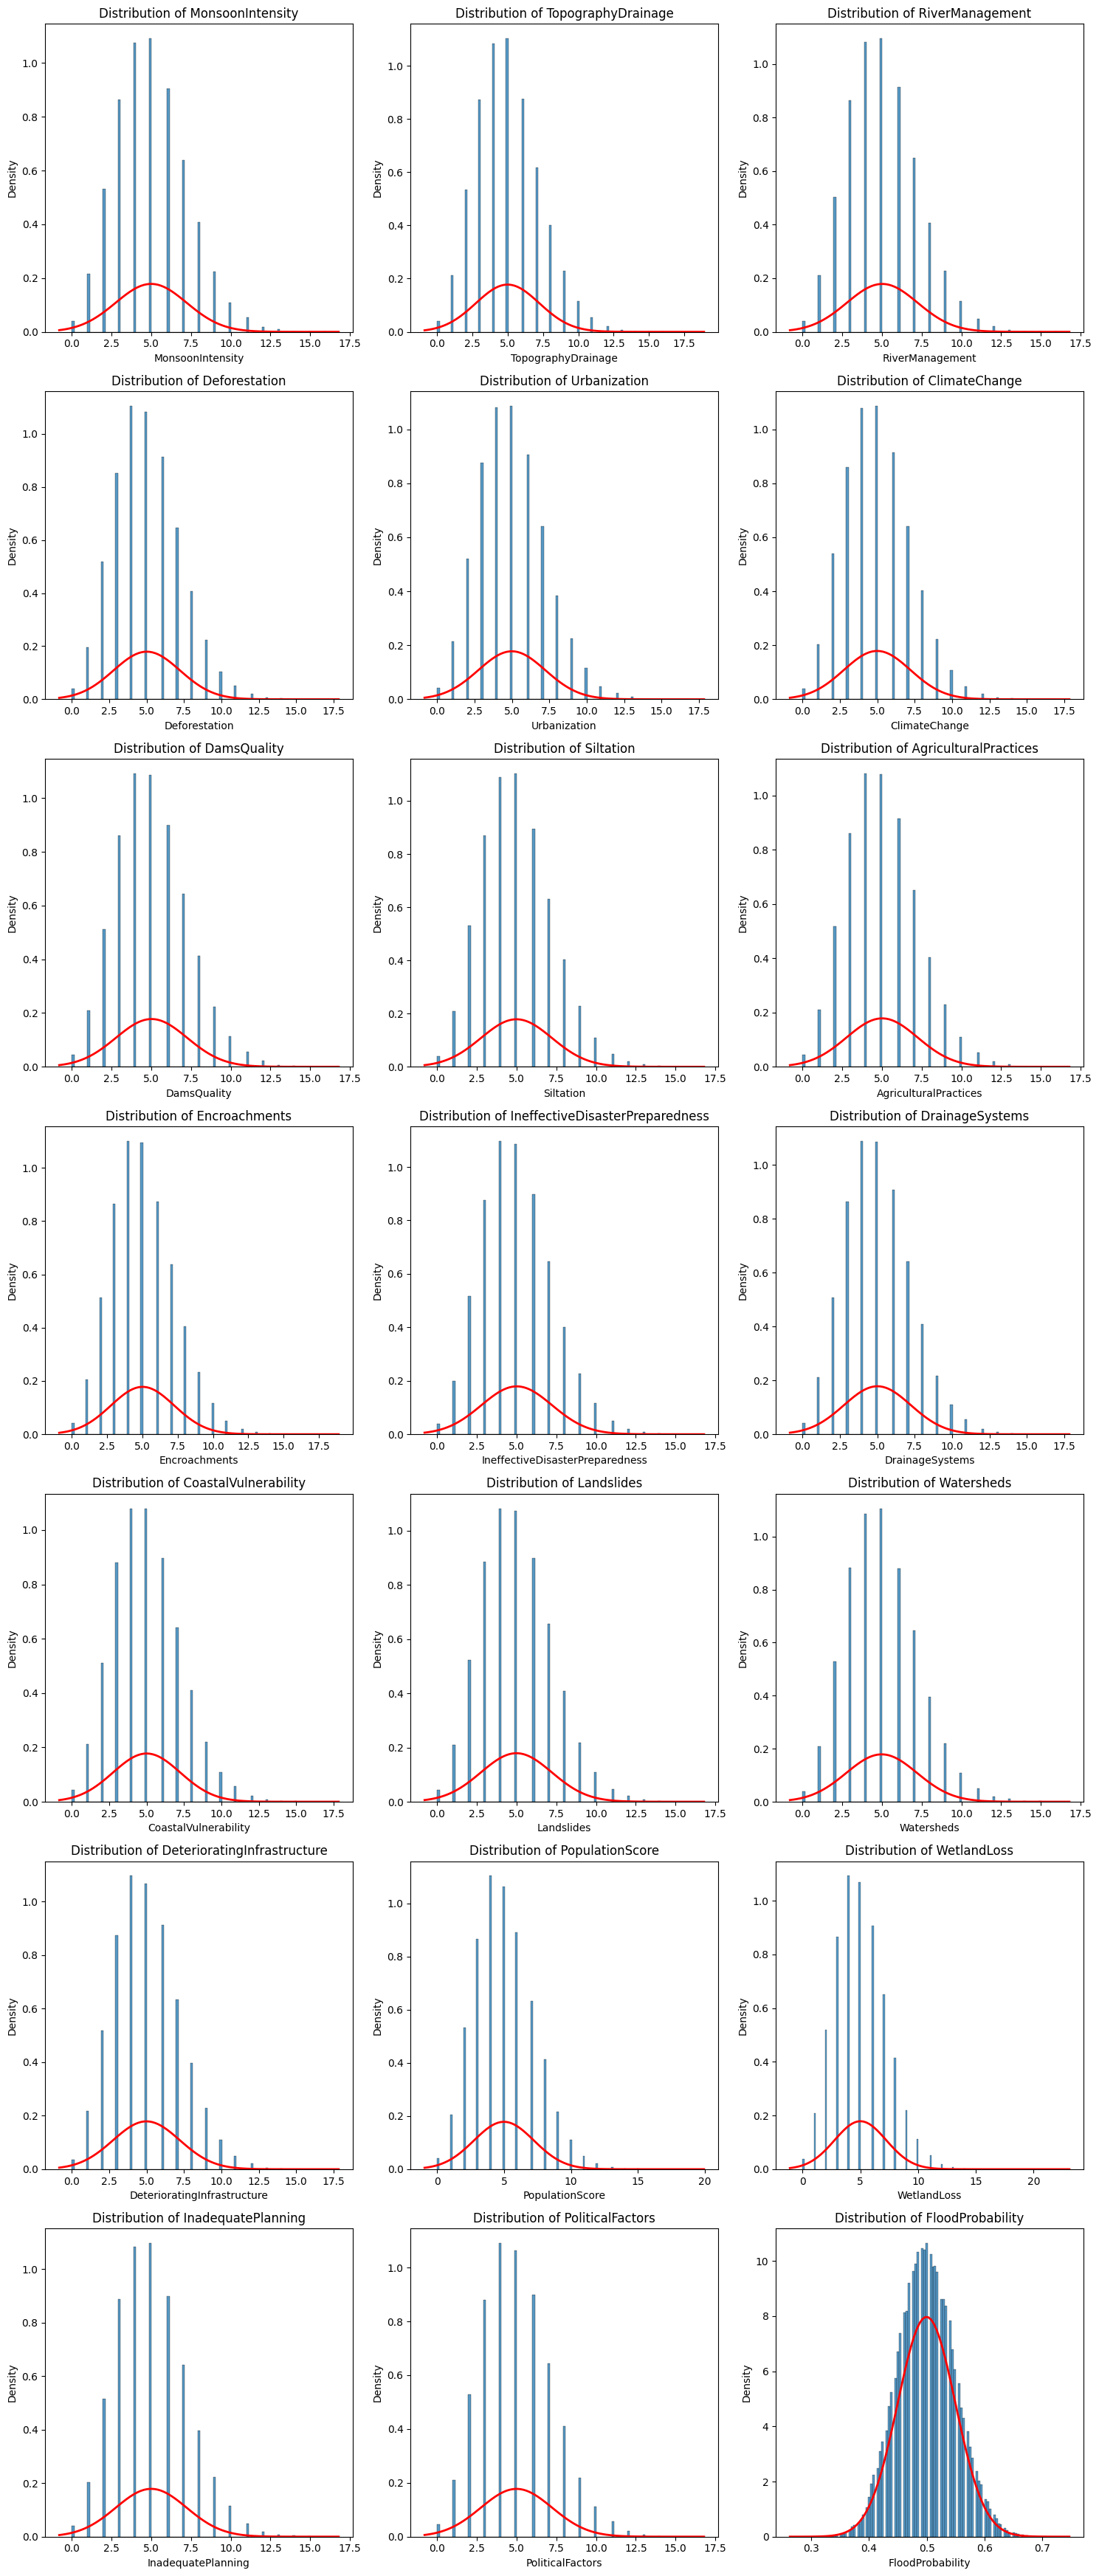

In [6]:

def plot_histogram(df):
    num_features = len(df.select_dtypes(include=['number']).columns)
    num_cols = 3
    num_rows = (num_features + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easier iteration

    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        ax = axes[i]
        sns.histplot(df[col], kde=False, ax=ax, stat="density")
        # Fit a normal distribution
        mu, std = norm.fit(df[col])
        xmin, xmax = ax.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)

       # Overlay the normal curve on the histogram
        ax.plot(x, p, 'r', linewidth=2)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Density')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_histogram(df)

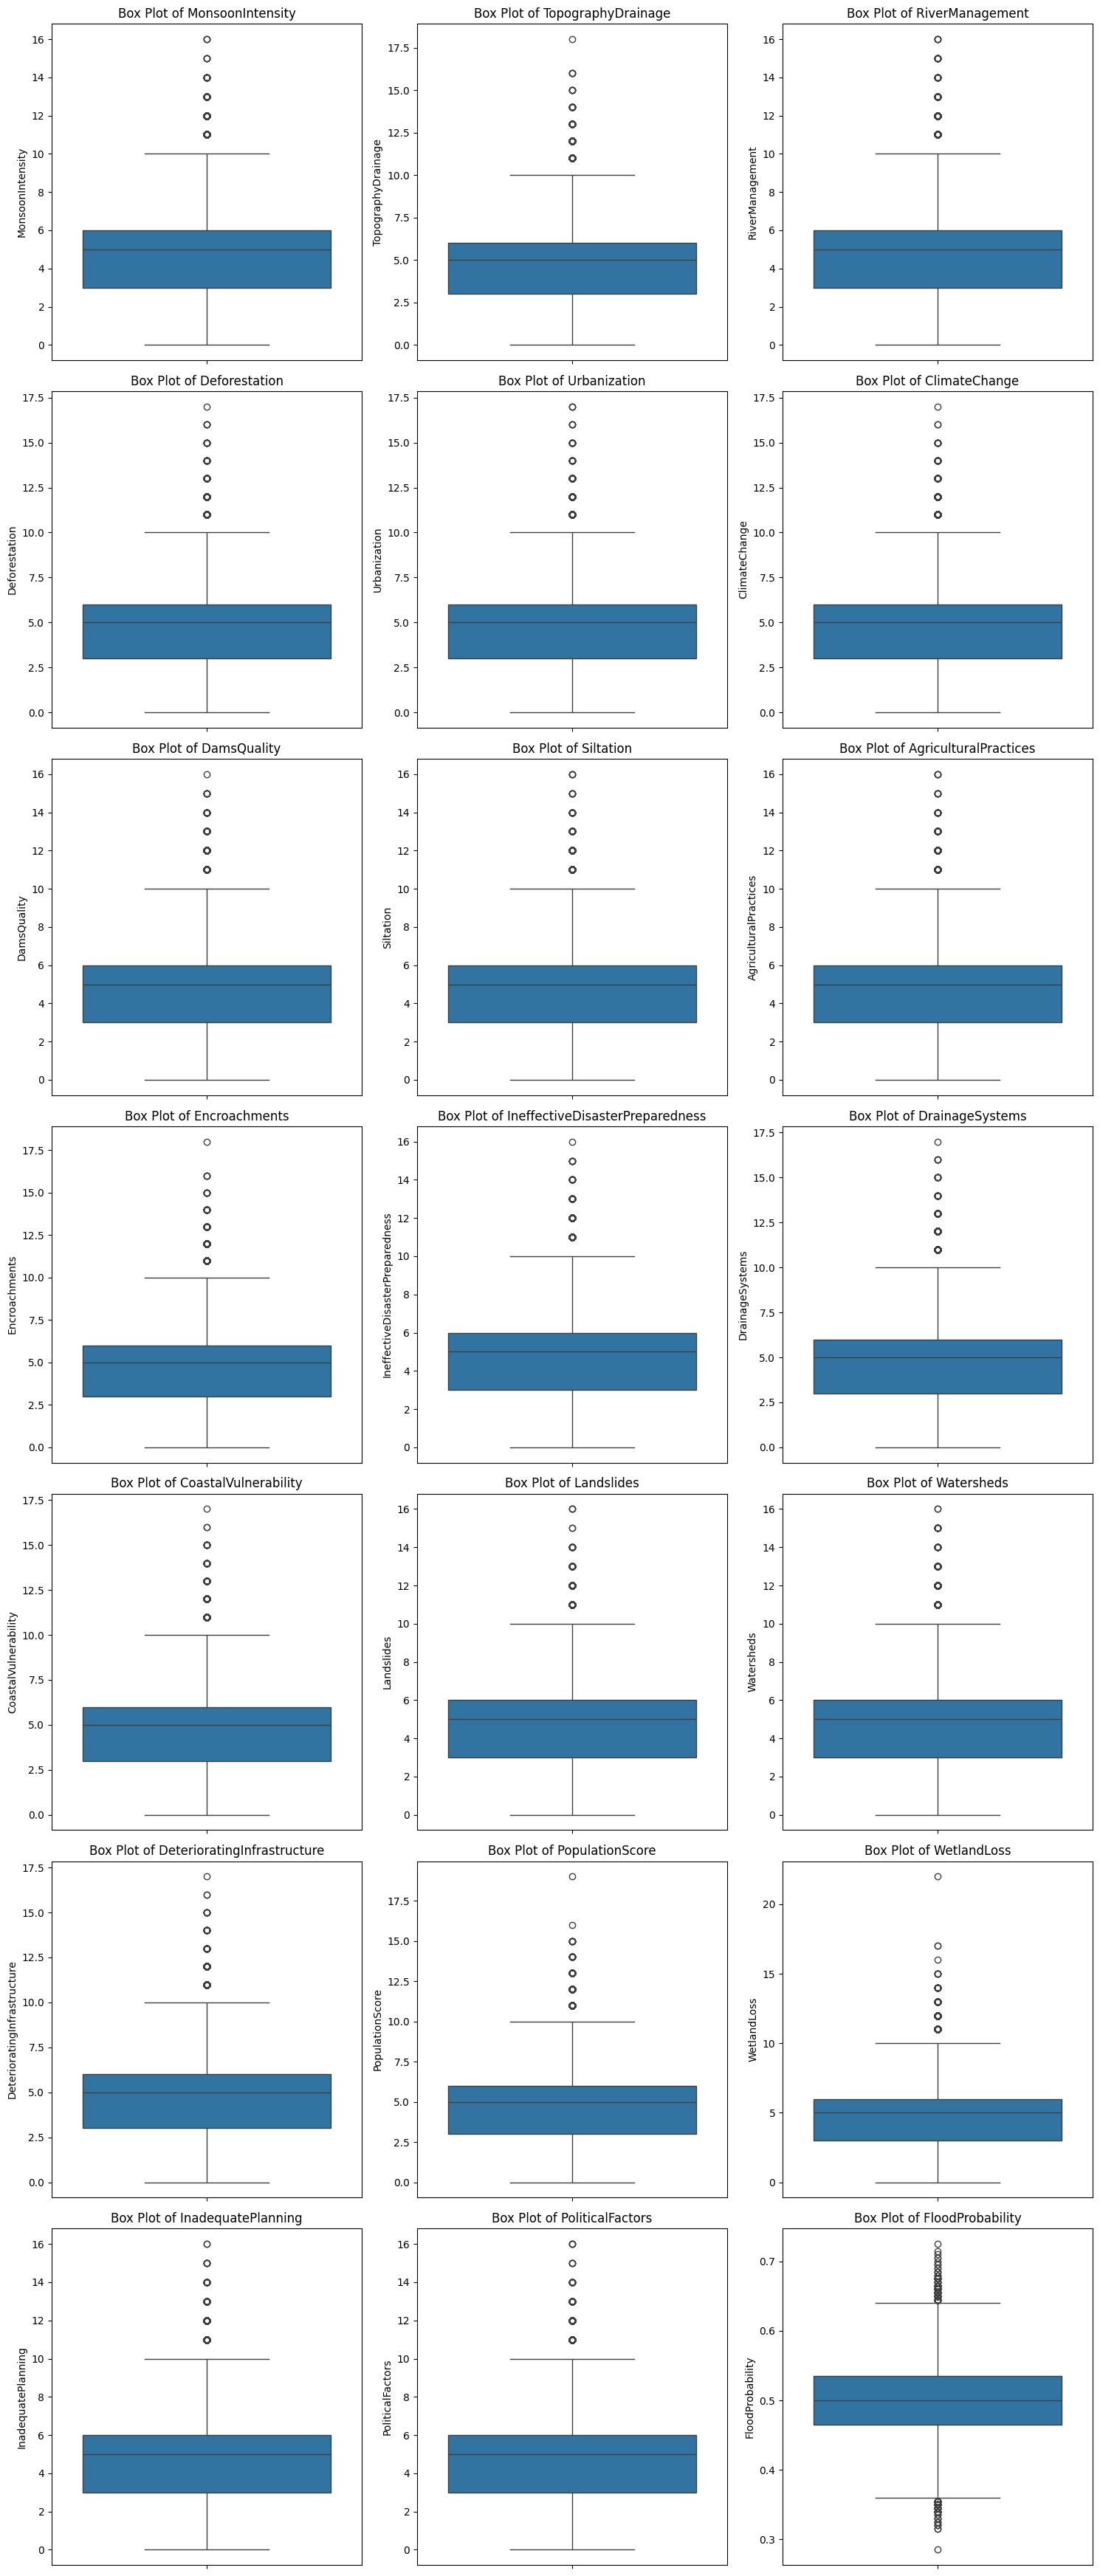

In [7]:

def plot_boxplot(df):
    num_features = len(df.select_dtypes(include=['number']).columns)
    num_cols = 3
    num_rows = (num_features + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        ax = axes[i]
        sns.boxplot(y=df[col], ax=ax)
        ax.set_title(f'Box Plot of {col}')
        ax.set_ylabel(col)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_boxplot(df)

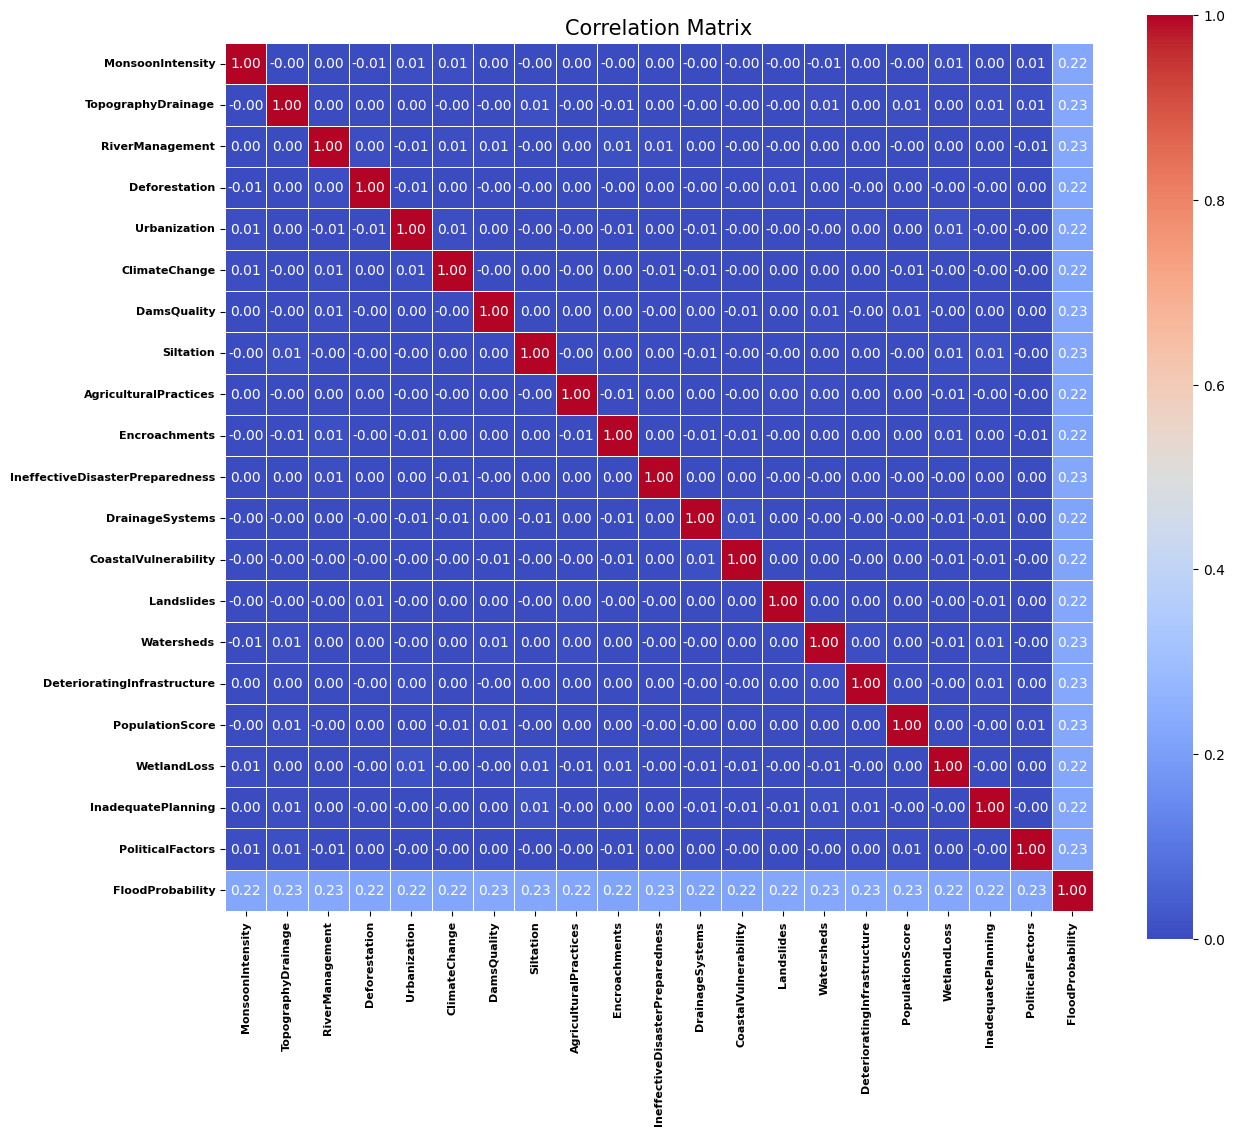

In [8]:
corr_matrix = df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, vmax=1, vmin=0, center=0.5,annot=True, fmt=".2f", square=True,
            linewidths=.5, cmap='coolwarm')
plt.title('Correlation Matrix', fontsize=15)
plt.xticks(fontsize=8,fontweight='bold')
plt.yticks(fontsize=8,fontweight='bold')
plt.show()

In [9]:

# Dropping the target value and separating it from the dataset
X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state for reproducibility

# Now you have X_train, X_test, y_train, and y_test
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 20)
X_test shape: (10000, 20)
y_train shape: (40000,)
y_test shape: (10000,)


In [10]:
# Cap all feature values at 10
def cap_features(df, cap_value=10):
     numeric_columns = df.select_dtypes(include=['number']).columns
     df[numeric_columns] = np.minimum(df[numeric_columns], cap_value)
     return df

# Apply capping to training and test data
X_train = cap_features(X_train, cap_value=10)
X_test = cap_features(X_test, cap_value=10)

# Verify (Optional: Check if any value exceeds the cap)
print((X_train > 10).any().any())  # Should return False
print((X_test > 10).any().any())   # Should return False


False
False


**Feature Engineering**

In [11]:
#Environmental Pressure
X_train['EnvironmentalPressure'] = X_train[['Deforestation', 'WetlandLoss', 'Siltation']].mean(axis=1)
X_test['EnvironmentalPressure'] = X_test[['Deforestation', 'WetlandLoss', 'Siltation']].mean(axis=1)
X_train['InfrastructureVulnerability'] = (X_train['DrainageSystems'] + X_train['DamsQuality']) / (1 + X_train['DeterioratingInfrastructure'])
X_test['InfrastructureVulnerability'] = (X_test['DrainageSystems'] + X_test['DamsQuality']) / (1 + X_test['DeterioratingInfrastructure'])
X_train['UrbanizationStress'] = X_train['Urbanization'] / (1 + X_train['DrainageSystems'])
X_test['UrbanizationStress'] = X_test['Urbanization'] / (1 + X_test['DrainageSystems'])
X_train['PreparednessDeficiency'] = X_train[['IneffectiveDisasterPreparedness', 'InadequatePlanning']].mean(axis=1)
X_test['PreparednessDeficiency'] = X_test[['IneffectiveDisasterPreparedness', 'InadequatePlanning']].mean(axis=1)
X_train['RainfallDrainageMismatch'] = X_train['MonsoonIntensity'] / (1 + X_train['DrainageSystems'])
X_test['RainfallDrainageMismatch'] = X_test['MonsoonIntensity'] / (1 + X_test['DrainageSystems'])
X_train['PopulationEnvStress'] = X_train['PopulationScore'] * (X_train['Deforestation'] + X_train['Urbanization'])
X_test['PopulationEnvStress'] = X_test['PopulationScore'] * (X_test['Deforestation'] + X_test['Urbanization'])


Re computing the correaltion matrix after feature engineering

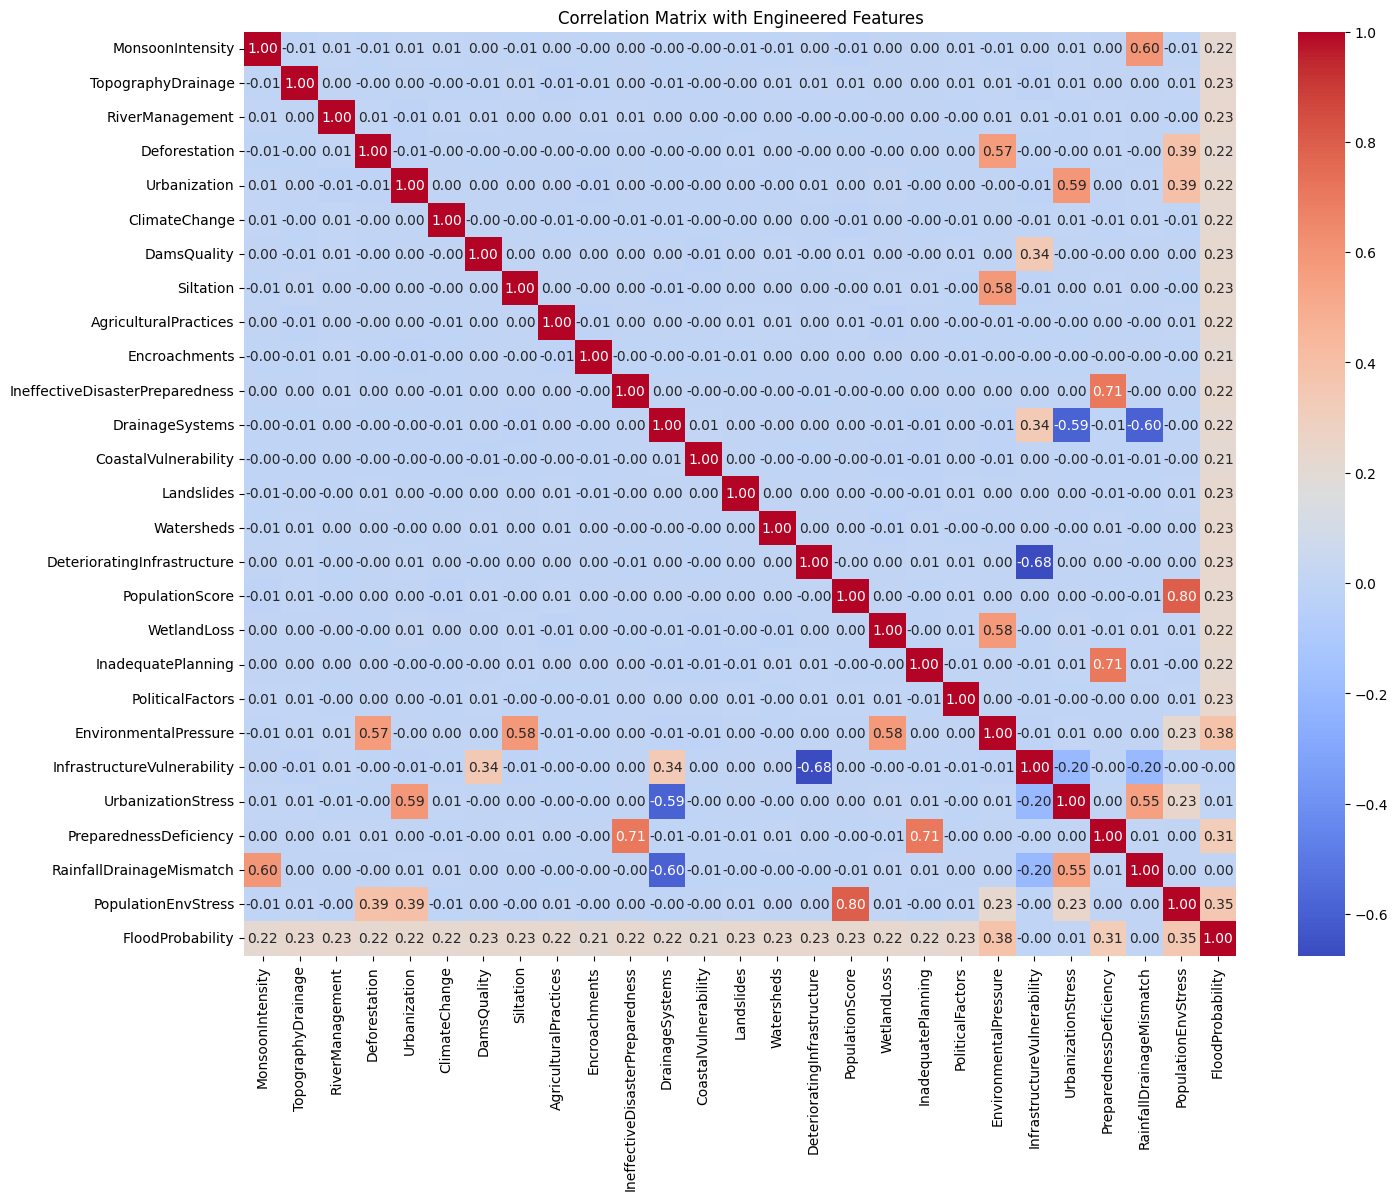

In [12]:
X_train_with_target = X_train.copy()
X_train_with_target['FloodProbability'] = y_train

# Compute the correlation matrix
correlation_matrix = X_train_with_target.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix with Engineered Features")
plt.show()

Feature Selection using Random Forest

In [13]:

# Use RandomForestRegressor for continuous target variable
model_rf = RandomForestRegressor(random_state=42)
# If it's a classification task, use RandomForestClassifier

model_rf.fit(X_train, y_train)  # Fit on training data

# Feature importances
feature_importances_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances_rf)

# Select top features (e.g., top 10)
top_features_rf = feature_importances_rf['Feature'].head(10).values
X_train_rf = X_train[top_features_rf]
X_test_rf = X_test[top_features_rf]

                            Feature  Importance
20            EnvironmentalPressure    0.129539
25              PopulationEnvStress    0.096747
23           PreparednessDeficiency    0.089034
1                TopographyDrainage    0.046605
6                       DamsQuality    0.045946
19                 PoliticalFactors    0.045453
14                       Watersheds    0.044614
2                   RiverManagement    0.044328
15      DeterioratingInfrastructure    0.043807
8             AgriculturalPractices    0.043586
13                       Landslides    0.043412
5                     ClimateChange    0.043223
12             CoastalVulnerability    0.042630
9                     Encroachments    0.041491
0                  MonsoonIntensity    0.040487
11                  DrainageSystems    0.038167
21      InfrastructureVulnerability    0.017980
4                      Urbanization    0.016369
24         RainfallDrainageMismatch    0.013183
7                         Siltation    0

In [14]:
top_features_rf

array(['EnvironmentalPressure', 'PopulationEnvStress',
       'PreparednessDeficiency', 'TopographyDrainage', 'DamsQuality',
       'PoliticalFactors', 'Watersheds', 'RiverManagement',
       'DeterioratingInfrastructure', 'AgriculturalPractices'],
      dtype=object)

Feature selcting using XGBoost

In [15]:

# Example: Assume classification task
model_xgb = XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='logloss')
# If regression task, use XGBRegressor

model_xgb.fit(X_train, y_train)

# Feature importances
feature_importances_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances_xgb)

# Select top features
top_features_xgb = feature_importances_xgb['Feature'].head(10).values
X_train_xgb = X_train[top_features_xgb]
X_test_xgb = X_test[top_features_xgb]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:52:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                            Feature  Importance
20            EnvironmentalPressure    0.114116
23           PreparednessDeficiency    0.086410
25              PopulationEnvStress    0.067234
15      DeterioratingInfrastructure    0.058436
19                 PoliticalFactors    0.055344
12             CoastalVulnerability    0.053550
14                       Watersheds    0.053329
13                       Landslides    0.053315
6                       DamsQuality    0.053049
8             AgriculturalPractices    0.052975
2                   RiverManagement    0.051832
11                  DrainageSystems    0.051454
9                     Encroachments    0.047149
5                     ClimateChange    0.046953
0                  MonsoonIntensity    0.042972
1                TopographyDrainage    0.042240
4                      Urbanization    0.030317
16                  PopulationScore    0.009021
21      InfrastructureVulnerability    0.007278
17                      WetlandLoss    0

In [16]:
top_features_xgb

array(['EnvironmentalPressure', 'PreparednessDeficiency',
       'PopulationEnvStress', 'DeterioratingInfrastructure',
       'PoliticalFactors', 'CoastalVulnerability', 'Watersheds',
       'Landslides', 'DamsQuality', 'AgriculturalPractices'], dtype=object)

Feature Selction using LGBoost

In [17]:
from lightgbm import LGBMRegressor

# Example: Assume classification task
model_lgbm = LGBMRegressor(random_state=42)
# If regression task, use LGBMRegressor

model_lgbm.fit(X_train, y_train)

# Feature importances
feature_importances_lgbm = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances_lgbm)

# Select top features
top_features_lgbm = feature_importances_lgbm['Feature'].head(10).values
X_train_lgbm = X_train[top_features_lgbm]
X_test_lgbm = X_test[top_features_lgbm]


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 655
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 26
[LightGBM] [Info] Start training from score 0.499519
                            Feature  Importance
23           PreparednessDeficiency         236
9                     Encroachments         185
12             CoastalVulnerability         179
5                     ClimateChange         178
1                TopographyDrainage         177
11                  DrainageSystems         175
13                       Landslides         171
0                  MonsoonIntensity         170
15      DeterioratingInfrastructure         167
8             AgriculturalPractices         165
2                   RiverManagement         165
6                  

In [18]:
top_features_lgbm

array(['PreparednessDeficiency', 'Encroachments', 'CoastalVulnerability',
       'ClimateChange', 'TopographyDrainage', 'DrainageSystems',
       'Landslides', 'MonsoonIntensity', 'DeterioratingInfrastructure',
       'AgriculturalPractices'], dtype=object)

Selcted Features and storing them into the new variable

In [19]:
selected_features = set(top_features_rf) | set(top_features_xgb) | set(top_features_lgbm)

# Create datasets with the selected features
X_train_selected = X_train[list(selected_features)]
X_test_selected = X_test[list(selected_features)]

print(f"Final selected features: {list(selected_features)}")

Final selected features: ['Landslides', 'DrainageSystems', 'EnvironmentalPressure', 'CoastalVulnerability', 'PopulationEnvStress', 'ClimateChange', 'PreparednessDeficiency', 'TopographyDrainage', 'RiverManagement', 'Encroachments', 'Watersheds', 'PoliticalFactors', 'DeterioratingInfrastructure', 'DamsQuality', 'AgriculturalPractices', 'MonsoonIntensity']


Model Training, Evaluation and hypertuning


Training RandomForest Baseline...
CPU Usage: 26.5%
Memory Usage: 15.4%
CPU Usage: 69.6%
Memory Usage: 17.5%
RandomForest - Training Time: 39.79 seconds
RandomForest - Inference Time per Sample: 0.000037 seconds
RandomForest Baseline Results:
Train RMSE: 0.0089, Test RMSE: 0.0233
Train R2: 0.9685, Test R2: 0.7817
RandomForest Baseline Bias-Variance Trade-off:
Bias: 0.0001
Variance: 0.0019
Train RMSE: 0.0089
Test RMSE: 0.0233


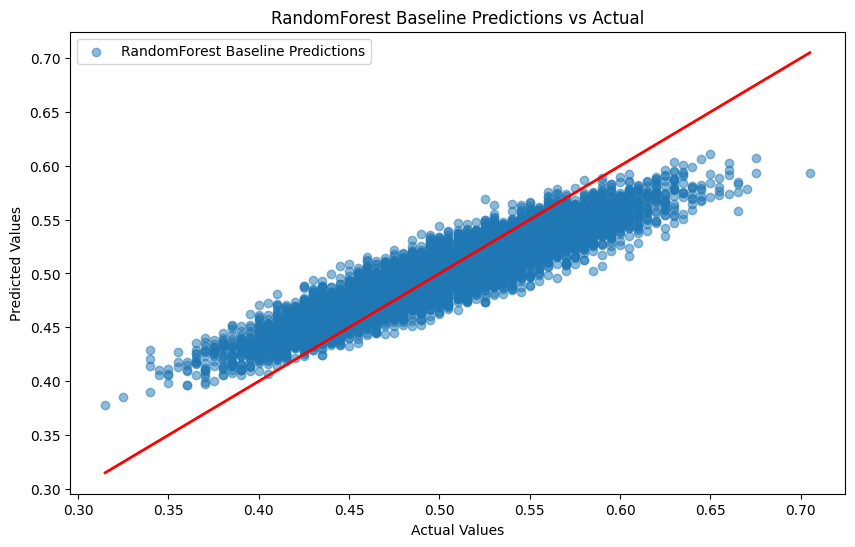


Tuning RandomForest with GridSearchCV...


In [ ]:
# Utility function to log CPU and memory usage
def log_resource_usage():
    print(f"CPU Usage: {psutil.cpu_percent()}%")
    print(f"Memory Usage: {psutil.virtual_memory().percent}%")

# Utility function to calculate training time, inference speed, and print resources
def measure_time(model, X_train, y_train, model_name="Model"):
    log_resource_usage()
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    log_resource_usage()

    # Measure inference speed
    start_time = time.time()
    model.predict(X_train)
    inference_time = (time.time() - start_time) / len(X_train)  # Time per sample
    print(f"{model_name} - Training Time: {training_time:.2f} seconds")
    print(f"{model_name} - Inference Time per Sample: {inference_time:.6f} seconds")
    return training_time, inference_time

# Utility function to calculate bias and variance
def calculate_bias_variance(model, X_train, y_train, X_test, y_test):
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Training and testing errors
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    # Bias and variance calculation
    bias = np.square(y_train - train_preds).mean()
    variance = np.var(train_preds)

    print(f"Bias: {bias:.4f}")
    print(f"Variance: {variance:.4f}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")

    return bias, variance

# Define parameter grids for hyperparameter tuning
param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 6, 10],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'LightGBM': {
        'num_leaves': [31, 50, 100],
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [100, 200, 300],
        'max_depth': [-1, 10, 20]
    }
}

# Initialize models
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42)
}

# Step-by-step for each model: baseline training, hyperparameter tuning, and performance evaluation
for model_name, model in models.items():
    # Step 1: Train the baseline model
    print(f"\nTraining {model_name} Baseline...")
    baseline_model = model
    baseline_training_time, baseline_inference_time = measure_time(baseline_model, X_train_selected, y_train, model_name=model_name)

    y_train_pred = baseline_model.predict(X_train_selected)
    y_test_pred = baseline_model.predict(X_test_selected)

    baseline_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    baseline_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    baseline_train_r2 = r2_score(y_train, y_train_pred)
    baseline_test_r2 = r2_score(y_test, y_test_pred)

    print(f"{model_name} Baseline Results:")
    print(f"Train RMSE: {baseline_train_rmse:.4f}, Test RMSE: {baseline_test_rmse:.4f}")
    print(f"Train R2: {baseline_train_r2:.4f}, Test R2: {baseline_test_r2:.4f}")

    # Step 2: Calculate bias and variance for the baseline model
    print(f"{model_name} Baseline Bias-Variance Trade-off:")
    bias, variance = calculate_bias_variance(baseline_model, X_train_selected, y_train, X_test_selected, y_test)

    # Step 3: Visualize Predicted vs Actual for baseline
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.5, label=f'{model_name} Baseline Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
    plt.title(f'{model_name} Baseline Predictions vs Actual')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.show()

    # Step 4: Hyperparameter tuning with GridSearchCV
    print(f"\nTuning {model_name} with GridSearchCV...")
    start_time = time.time()
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    grid_search.fit(X_train_selected, y_train)
    grid_search_time = time.time() - start_time

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_cv_rmse = np.sqrt(-grid_search.best_score_)

    print(f"{model_name} Hyperparameter Tuning Results:")
    print(f"Best Parameters: {best_params}")
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"GridSearchCV Time Taken: {grid_search_time:.2f} seconds")

    # Step 5: Evaluate the best model on the test set
    print(f"\nEvaluating {model_name} on the Test Set...")
    y_test_final = best_model.predict(X_test_selected)
    final_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_final))
    final_test_r2 = r2_score(y_test, y_test_final)

    print(f"{model_name} Final Test Set Results:")
    print(f"Test RMSE: {final_test_rmse:.4f}")
    print(f"Test R2: {final_test_r2:.4f}")

    # Calculate bias and variance for the tuned model
    print(f"{model_name} Tuned Bias-Variance Trade-off:")
    bias, variance = calculate_bias_variance(best_model, X_train_selected, y_train, X_test_selected, y_test)

    # Step 6: Visualize Predicted vs Actual for the tuned model
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_test_final, alpha=0.5, label=f'{model_name} Tuned Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
    plt.title(f'{model_name} Tuned Predictions vs Actual')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.show()

    # Step 7: Visualize feature importances for the tuned model
    if model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
        feature_importances = pd.Series(best_model.feature_importances_, index=X_train_selected.columns)
        feature_importances.nlargest(10).plot(kind='barh', figsize=(10, 6))
        plt.title(f"Top 10 Feature Importances for {model_name}")
        plt.show()
